In [ ]:
# =====================================================
# COLAB EVALUATION SCRIPT - BAB V SKRIPSI
# =====================================================
# Jalankan cell ini di Google Colab.
# Pastikan file dataset dan model (.pth) sudah ada di Google Drive Anda.
# =====================================================

# ------------------------------------------------------------------
# 1. INSTALL & MOUNT DRIVE
# ------------------------------------------------------------------
!pip install -q tqdm scikit-learn matplotlib seaborn pandas numpy torchvision

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ------------------------------------------------------------------
# 2. IMPORT LIBRARY
# ------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from scipy.interpolate import PchipInterpolator

warnings.filterwarnings("ignore")

In [ ]:
# ------------------------------------------------------------------
# 3. GPU CHECK
# ------------------------------------------------------------------
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"[GPU] {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("⚠️  Using CPU (recommended: enable GPU in Colab)")

CUDA Available: True
[GPU] Tesla T4


In [ ]:
# ------------------------------------------------------------------
# 4. KONFIGURASI (sesuaikan dengan path Drive ANDA)
# ------------------------------------------------------------------
class Config:
    # ---------- SESUAIKAN PATH INI ----------
    BASE_DIR = "/content/drive/MyDrive/DataSet/ptbdb/All_Assets"   # ganti jika berbeda
    # -----------------------------------------
    DATASET_DIR = os.path.join(BASE_DIR, "dataset_images_3class")
    OUTPUT_DIR = os.path.join(BASE_DIR, "multitask_outputs")
    TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
    VAL_CSV   = os.path.join(BASE_DIR, "val.csv")
    TEST_CSV  = os.path.join(BASE_DIR, "test.csv")
    IMAGE_SIZE = 224
    BATCH_SIZE = 128
    NUM_WORKERS = 4
    DEVICE = device
    EPOCHS = 15              # untuk cross-validation
    LEARNING_RATE = 1e-4
    PATIENCE = 5

CFG = Config()
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print("✅ Config loaded.")
print(f"📁 Output akan disimpan di: {CFG.OUTPUT_DIR}")


✅ Config loaded.
📁 Output akan disimpan di: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs


In [ ]:
# ------------------------------------------------------------------
# 5. TRANSFORM (sama seperti training)
# ------------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [ ]:
# ------------------------------------------------------------------
# 6. DATASET (sama seperti training)
# ------------------------------------------------------------------
class ECGDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        self.label_map = {
            "Normal": 0,
            "Myocardial_Infarction": 1,
            "Other_Heart_Disease": 2
        }
        self.feature_cols = ['HR','RR','PR','QRS','QT','QTc','AXIS','RV5','SV1','R_plus_S']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row['patient_id']
        label_name = row['label']
        image_path = os.path.join(self.image_dir, label_name, f"{patient_id}.png")
        if not os.path.exists(image_path):
            image_path = image_path.replace(".png", ".jpg")
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        class_label = torch.tensor(self.label_map[label_name], dtype=torch.long)
        regression_target = torch.tensor(row[self.feature_cols].values.astype(np.float32), dtype=torch.float32)
        return image, class_label, regression_target


In [ ]:

# ------------------------------------------------------------------
# 7. MODEL MULTI-TASK
# ------------------------------------------------------------------
class MultiTaskModel(nn.Module):
    def __init__(self, backbone_name, num_classes=3, num_features=10):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == "resnet34":
            backbone = models.resnet34(pretrained=True)
            in_features = backbone.fc.in_features
            self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        elif backbone_name == "vgg16":
            backbone = models.vgg16(pretrained=True)
            self.feature_extractor = backbone.features
            self.avgpool = backbone.avgpool
            self.vgg_classifier = nn.Sequential(*list(backbone.classifier.children())[:-1])
            in_features = 4096
        elif backbone_name == "densenet121":
            backbone = models.densenet121(pretrained=True)
            self.feature_extractor = backbone.features
            in_features = backbone.classifier.in_features
        else:
            raise ValueError("Unsupported backbone")

        self.classifier = nn.Linear(in_features, num_classes)
        self.regressor = nn.Linear(in_features, num_features)

    def forward(self, x):
        if self.backbone_name == "resnet34":
            x = self.feature_extractor(x)
            x = torch.flatten(x, 1)
        elif self.backbone_name == "vgg16":
            x = self.feature_extractor(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            x = self.vgg_classifier(x)
        elif self.backbone_name == "densenet121":
            x = self.feature_extractor(x)
            x = nn.functional.relu(x)
            x = nn.functional.adaptive_avg_pool2d(x, (1,1))
            x = torch.flatten(x, 1)
        class_out = self.classifier(x)
        reg_out = self.regressor(x)
        return class_out, reg_out


In [ ]:

# ------------------------------------------------------------------
# 8. LOAD TEST DATASET
# ------------------------------------------------------------------
test_dataset = ECGDataset(CFG.TEST_CSV, CFG.DATASET_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

class_names = ["Normal", "Myocardial_Infarction", "Other_Heart_Disease"]
print(f"🧪 Test samples: {len(test_dataset)}")


🧪 Test samples: 78


In [ ]:

# ------------------------------------------------------------------
# 9. LOAD BEST MODELS (dari hasil training sebelumnya)
# ------------------------------------------------------------------
def load_model(backbone):
    model = MultiTaskModel(backbone).to(CFG.DEVICE)
    weights_path = os.path.join(CFG.OUTPUT_DIR, f"best_{backbone}.pth")
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"❌ Weight tidak ditemukan: {weights_path}")
    model.load_state_dict(torch.load(weights_path, map_location=CFG.DEVICE))
    model.eval()
    return model

print("\n📥 Loading trained models ...")
vgg16_model = load_model("vgg16")
resnet34_model = load_model("resnet34")
densenet121_model = load_model("densenet121")
print("✅ All models loaded.")



📥 Loading trained models ...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 118MB/s]


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 137MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s]


✅ All models loaded.


In [ ]:

# ------------------------------------------------------------------
# 10. FUNGSI EVALUASI MODEL TUNGGAL
# ------------------------------------------------------------------
def evaluate_model(model, loader, desc="Evaluating"):
    model.eval()
    all_preds = []
    all_labels = []
    all_reg_preds = []
    all_reg_targets = []

    with torch.no_grad():
        for images, labels, reg_targets in tqdm(loader, desc=desc):
            images = images.to(CFG.DEVICE)
            class_logits, reg_preds = model(images)
            preds = torch.argmax(class_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_reg_preds.append(reg_preds.cpu().numpy())
            all_reg_targets.append(reg_targets.numpy())

    all_reg_preds = np.vstack(all_reg_preds)
    all_reg_targets = np.vstack(all_reg_targets)

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, report, cm, all_reg_preds, all_reg_targets


In [ ]:

# ------------------------------------------------------------------
# 11. EVALUASI MASING-MASING MODEL
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 EVALUASI PADA TEST SET - MODEL TUNGGAL")
print("="*60)

results = {}
models_dict = {
    "VGG16": vgg16_model,
    "ResNet34": resnet34_model,
    "DenseNet121": densenet121_model
}

for name, model in models_dict.items():
    acc, report, cm, _, _ = evaluate_model(model, test_loader, desc=f"{name}")
    results[name] = {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm
    }
    print(f"\n✅ {name} Accuracy: {acc:.4f}")
    print(f"   Classification Report (macro avg): F1 = {report['macro avg']['f1-score']:.4f}")



📊 EVALUASI PADA TEST SET - MODEL TUNGGAL


VGG16: 100%|██████████| 1/1 [01:25<00:00, 85.12s/it]



✅ VGG16 Accuracy: 0.9231
   Classification Report (macro avg): F1 = 0.8291


ResNet34: 100%|██████████| 1/1 [00:13<00:00, 13.87s/it]



✅ ResNet34 Accuracy: 0.9103
   Classification Report (macro avg): F1 = 0.8194


DenseNet121: 100%|██████████| 1/1 [00:13<00:00, 13.97s/it]


✅ DenseNet121 Accuracy: 1.0000
   Classification Report (macro avg): F1 = 1.0000


In [ ]:

# ------------------------------------------------------------------
# 12. EVALUASI ENSEMBLE SOFT VOTING
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 EVALUASI ENSEMBLE (Soft Voting)")
print("="*60)

def ensemble_evaluate(models, loader):
    all_preds = []
    all_labels = []
    all_reg_preds = []
    all_reg_targets = []

    with torch.no_grad():
        for images, labels, reg_targets in tqdm(loader, desc="Ensemble"):
            images = images.to(CFG.DEVICE)
            probs_list = []
            reg_list = []
            for model in models:
                class_logits, reg_preds = model(images)
                probs = torch.softmax(class_logits, dim=1)
                probs_list.append(probs)
                reg_list.append(reg_preds)
            avg_probs = torch.stack(probs_list).mean(dim=0)
            avg_reg = torch.stack(reg_list).mean(dim=0)
            preds = torch.argmax(avg_probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_reg_preds.append(avg_reg.cpu().numpy())
            all_reg_targets.append(reg_targets.numpy())

    all_reg_preds = np.vstack(all_reg_preds)
    all_reg_targets = np.vstack(all_reg_targets)

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, report, cm, all_reg_preds, all_reg_targets

models_list = [vgg16_model, resnet34_model, densenet121_model]
ens_acc, ens_report, ens_cm, ens_reg_preds, ens_reg_targets = ensemble_evaluate(models_list, test_loader)
print(f"\n✅ Ensemble Accuracy: {ens_acc:.4f}")
print(f"   Classification Report (macro avg): F1 = {ens_report['macro avg']['f1-score']:.4f}")

results["Ensemble"] = {
    "accuracy": ens_acc,
    "report": ens_report,
    "confusion_matrix": ens_cm,
    "reg_preds": ens_reg_preds,
    "reg_targets": ens_reg_targets
}



📊 EVALUASI ENSEMBLE (Soft Voting)


Ensemble: 100%|██████████| 1/1 [00:14<00:00, 14.93s/it]


✅ Ensemble Accuracy: 0.9744
   Classification Report (macro avg): F1 = 0.9571



📊 CONFUSION MATRICES


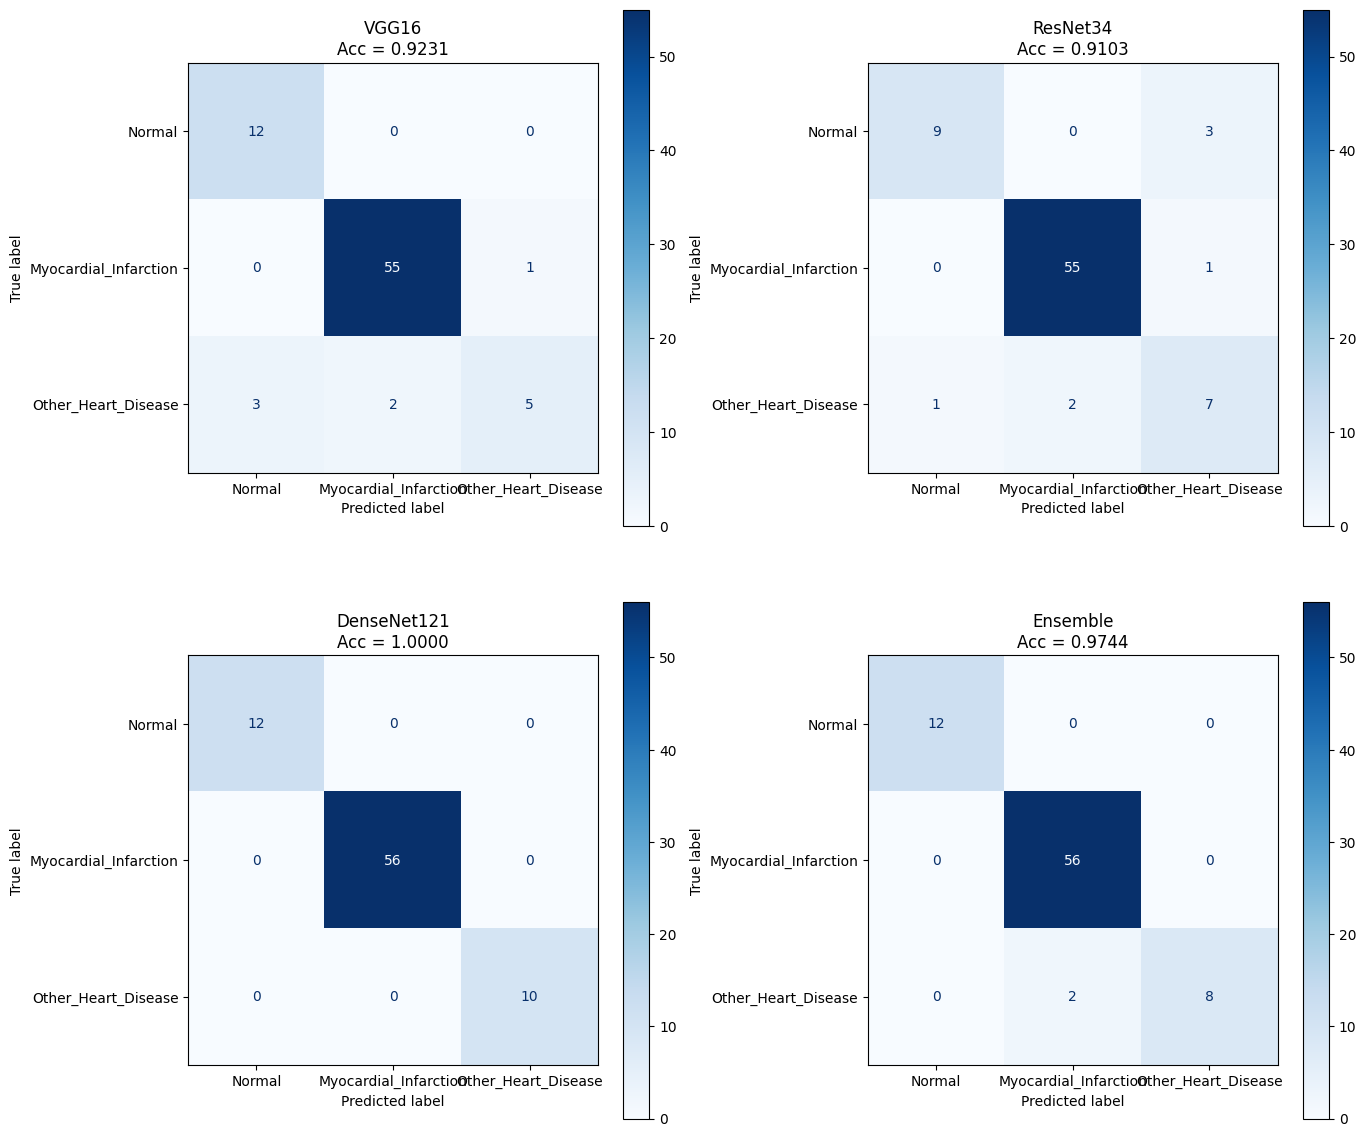

✅ Confusion matrix disimpan di: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/confusion_matrices_all.png


In [ ]:

# ------------------------------------------------------------------
# 13. VISUALISASI CONFUSION MATRIX (semua model + ensemble)
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    if idx >= 4:
        break
    cm = res["confusion_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], cmap="Blues", values_format="d")
    axes[idx].set_title(f"{name}\nAcc = {res['accuracy']:.4f}", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "confusion_matrices_all.png"), dpi=300)
plt.show()
print(f"✅ Confusion matrix disimpan di: {CFG.OUTPUT_DIR}/confusion_matrices_all.png")



📊 ROC CURVE PER MODEL & ENSEMBLE (One-vs-Rest)


  VGG16                     | Macro-Avg AUC = 0.9832
  ResNet34                  | Macro-Avg AUC = 0.9405
  DenseNet121               | Macro-Avg AUC = 1.0000
  Ensemble (Soft Voting)    | Macro-Avg AUC = 0.9985

💾 ROC curves saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/roc_curves_all_models.png


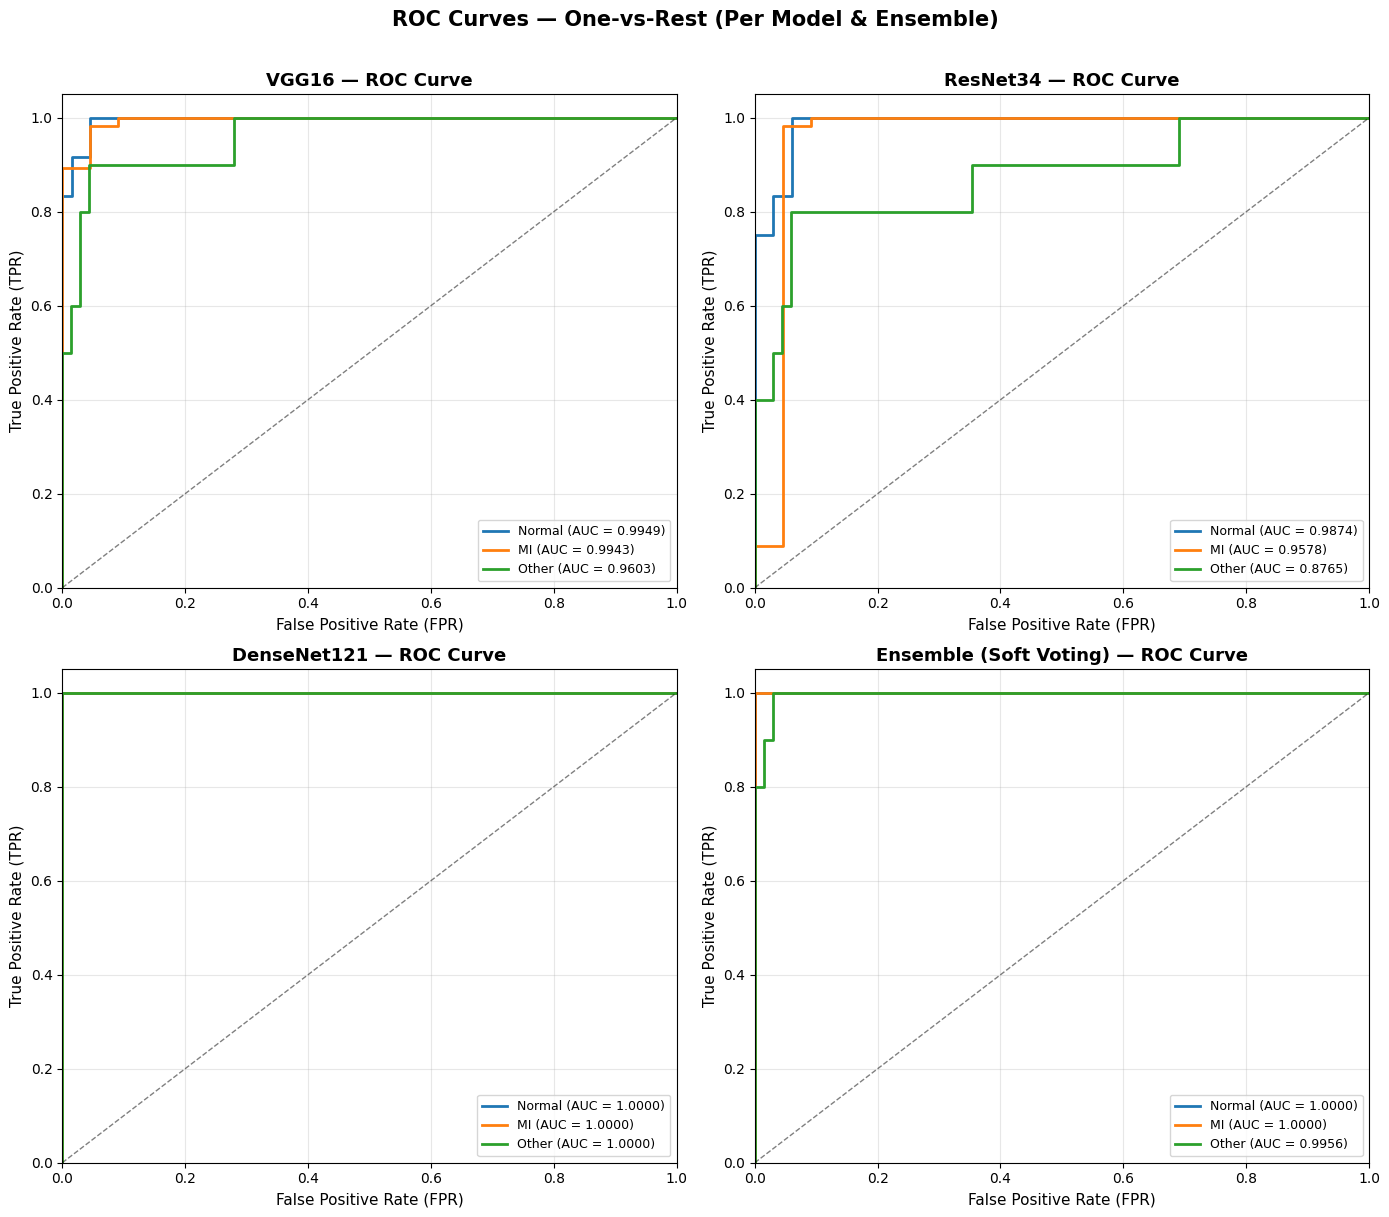


📋 Tabel AUC per Model:
                 Model  AUC Normal   AUC MI  AUC Other  Macro-Avg AUC
                 VGG16    0.994949 0.994318   0.960294       0.983187
              ResNet34    0.987374 0.957792   0.876471       0.940546
           DenseNet121    1.000000 1.000000   1.000000       1.000000
Ensemble (Soft Voting)    1.000000 1.000000   0.995588       0.998529
💾 AUC summary saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/auc_summary.csv
💾 AUC bar chart saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/auc_macro_comparison.png


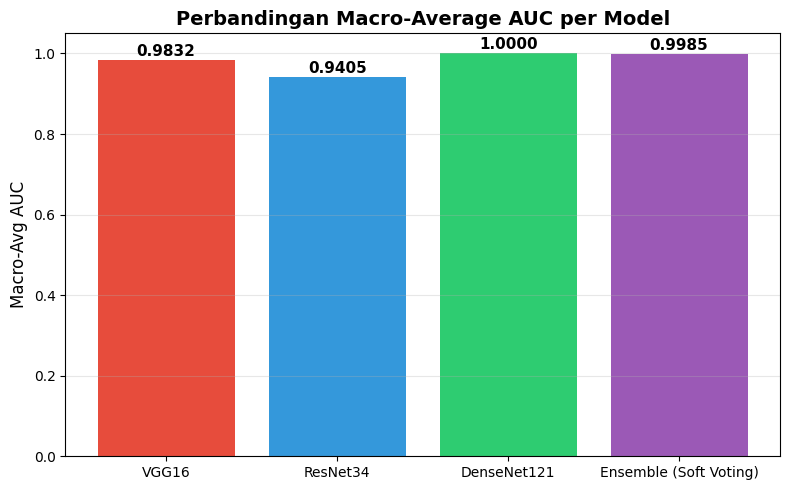

In [ ]:
# ------------------------------------------------------------------
# 13. ROC CURVE TIAP MODEL + ENSEMBLE (One-vs-Rest)
# ------------------------------------------------------------------
print("\n" + "=" * 90)
print("📊 ROC CURVE PER MODEL & ENSEMBLE (One-vs-Rest)")
print("=" * 90)

# --- Start of fix: Collect probabilities and true labels ---
all_probs_per_model = {name: [] for name in models_dict.keys()}
all_ensemble_probs = []
all_true_labels = []

# Ensure CLASS_NAMES and SHORT_LABELS are defined for this section
CLASS_NAMES = class_names # class_names was defined in UFzvz6V6lm46
SHORT_LABELS = {
    "Normal": "Normal",
    "Myocardial_Infarction": "MI",
    "Other_Heart_Disease": "Other"
}

with torch.no_grad():
    for images, labels, _ in tqdm(test_loader, desc="Collecting Probs for ROC"): # Added desc for clarity
        images = images.to(CFG.DEVICE)

        batch_individual_probs = [] # To store probabilities from individual models for this batch

        for name, model in models_dict.items():
            class_logits, _ = model(images)
            probs = torch.softmax(class_logits, dim=1).cpu().numpy() # (batch_size, num_classes)
            all_probs_per_model[name].append(probs) # Append the numpy array for this batch
            batch_individual_probs.append(probs) # Collect for ensemble calculation

        # Calculate ensemble probabilities for this batch
        if batch_individual_probs: # Check if there are probabilities to stack
            stacked_probs_batch = np.stack(batch_individual_probs, axis=0) # (num_models, batch_size, num_classes)
            ensemble_avg_probs_batch = stacked_probs_batch.mean(axis=0) # (batch_size, num_classes)
            all_ensemble_probs.append(ensemble_avg_probs_batch)

        all_true_labels.extend(labels.numpy())

# Gabungkan data yang sudah dikumpulkan
for name in all_probs_per_model:
    all_probs_per_model[name] = np.vstack(all_probs_per_model[name]) # Stack all batches for each model
ensemble_probs_all = np.vstack(all_ensemble_probs)
true_labels_all    = np.hstack(all_true_labels)
# --- End of fix ---

# Binarize true labels untuk multi-class ROC
n_classes = len(CLASS_NAMES)
y_true_bin = label_binarize(true_labels_all, classes=[0, 1, 2])  # (N, 3)

# Siapkan dict ROC data: per model + ensemble
roc_sources = {}
for name in models_dict.keys():
    roc_sources[name] = all_probs_per_model[name]
roc_sources["Ensemble (Soft Voting)"] = ensemble_probs_all

# ---- A) Plot ROC tiap model terpisah (2x2 grid) ----
roc_colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
roc_fig, roc_axes = plt.subplots(2, 2, figsize=(14, 12))

auc_summary = []  # untuk tabel ringkasan

for idx, (model_name, probs) in enumerate(roc_sources.items()):
    ax = roc_axes.flatten()[idx]
    model_aucs = {}
    for cls_idx, color in zip(range(n_classes), roc_colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, cls_idx], probs[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        model_aucs[CLASS_NAMES[cls_idx]] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{SHORT_LABELS[CLASS_NAMES[cls_idx]]} (AUC = {roc_auc:.4f})')
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
    ax.set_title(f'{model_name} — ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

    # Macro-average AUC
    macro_auc = np.mean(list(model_aucs.values()))
    auc_summary.append({
        "Model": model_name,
        **{f"AUC {SHORT_LABELS[c]}": model_aucs[c] for c in CLASS_NAMES},
        "Macro-Avg AUC": macro_auc
    })
    print(f"  {model_name:25s} | Macro-Avg AUC = {macro_auc:.4f}")

roc_fig.suptitle("ROC Curves — One-vs-Rest (Per Model & Ensemble)",
                 fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
roc_output_path = os.path.join(CFG.OUTPUT_DIR, "roc_curves_all_models.png")
roc_fig.savefig(roc_output_path, dpi=300, bbox_inches='tight')
print(f"\n💾 ROC curves saved to: {roc_output_path}")
plt.show()

# ---- B) Tabel AUC Ringkasan ----
auc_df = pd.DataFrame(auc_summary)
print("\n📋 Tabel AUC per Model:")
print(auc_df.to_string(index=False))
auc_csv_path = os.path.join(CFG.OUTPUT_DIR, "auc_summary.csv")
auc_df.to_csv(auc_csv_path, index=False)
print(f"💾 AUC summary saved to: {auc_csv_path}")

# ---- C) Plot Perbandingan Macro AUC (Bar Chart) ----
plt.figure(figsize=(8, 5))
bars = plt.bar(auc_df["Model"], auc_df["Macro-Avg AUC"],
               color=['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'])
plt.ylim(0, 1.05)
plt.ylabel('Macro-Avg AUC', fontsize=12)
plt.title('Perbandingan Macro-Average AUC per Model', fontsize=14, fontweight='bold')
for bar, val in zip(bars, auc_df["Macro-Avg AUC"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
auc_bar_path = os.path.join(CFG.OUTPUT_DIR, "auc_macro_comparison.png")
plt.savefig(auc_bar_path, dpi=300)
print(f"💾 AUC bar chart saved to: {auc_bar_path}")
plt.show()


  ROC CURVE PER MODEL & ENSEMBLE (One-vs-Rest) -- Publication Style
  VGG16                     | Micro=0.9915  Macro=0.9814
  ResNet34                  | Micro=0.9772  Macro=0.9388
  DenseNet121               | Micro=1.0000  Macro=0.9975
  Ensemble (Soft Voting)    | Micro=0.9988  Macro=0.9963

  [Saved] /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/roc_curves_per_model_ieee.png
  [Saved] /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/roc_curves_per_model_ieee.pdf


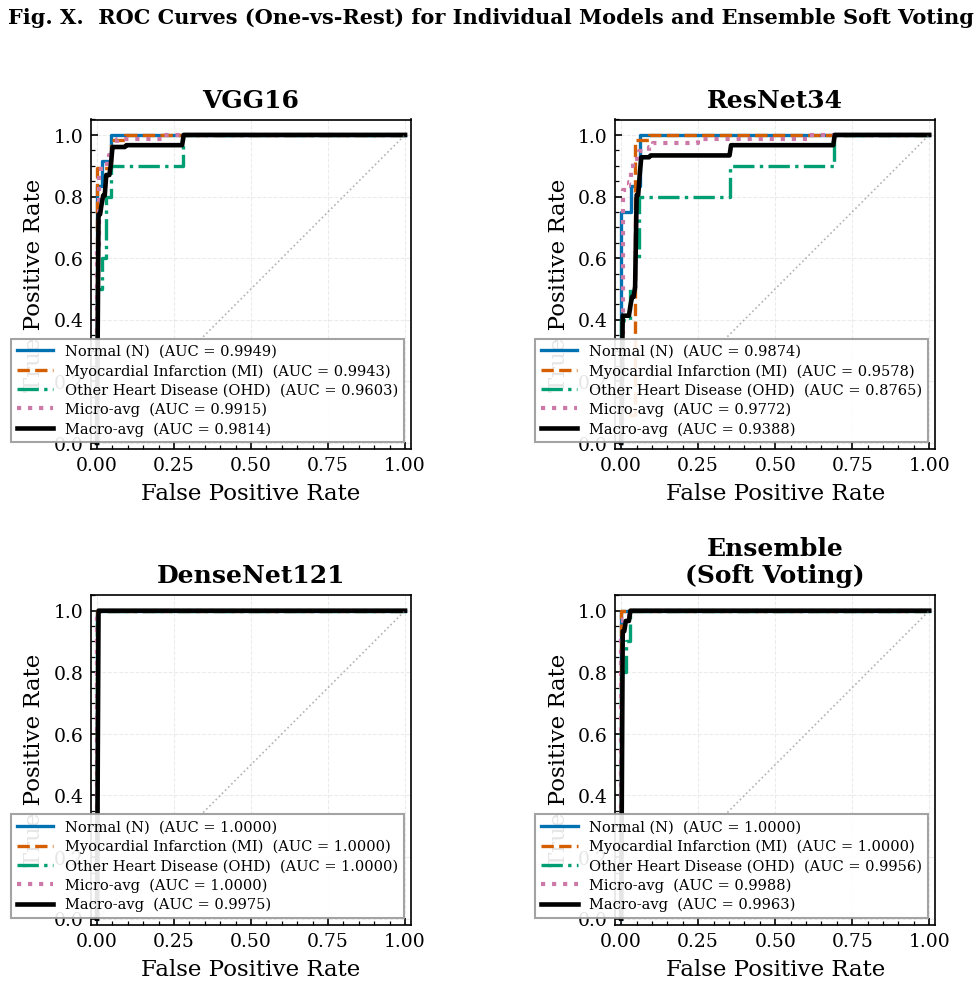

  [Saved] /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/roc_macro_combined_ieee.png


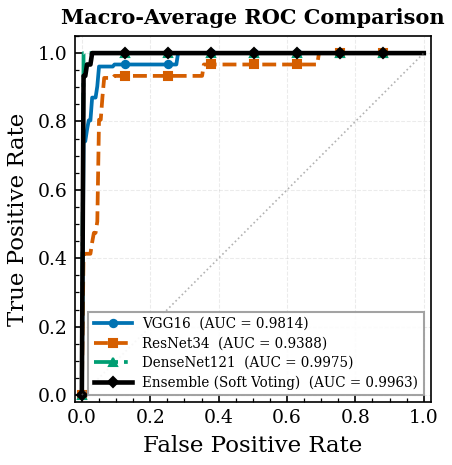


  AUC Summary Table:
                 Model  AUC Normal   AUC MI  AUC OHD  Micro-Avg AUC  Macro-Avg AUC
                 VGG16    0.994949 0.994318 0.960294       0.991453       0.981365
              ResNet34    0.987374 0.957792 0.876471       0.977153       0.938765
           DenseNet121    1.000000 1.000000 1.000000       1.000000       0.997487
Ensemble (Soft Voting)    1.000000 1.000000 0.995588       0.998849       0.996315
  [Saved] /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/auc_summary.csv
  [Saved] /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/auc_macro_comparison_ieee.png


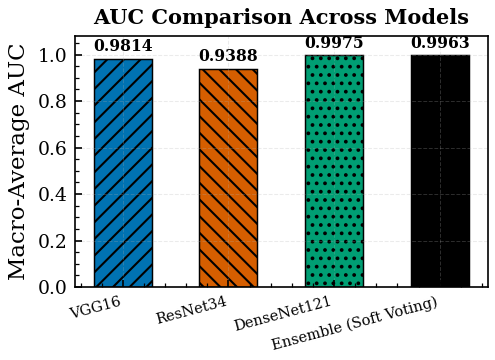

In [ ]:
# ------------------------------------------------------------------
# 13. ROC CURVE — IEEE / ELSEVIER PUBLICATION STYLE
# ------------------------------------------------------------------
print("\n" + "=" * 90)
print("  ROC CURVE PER MODEL & ENSEMBLE (One-vs-Rest) -- Publication Style")
print("=" * 90)



# =====================================================================
# 13-A. MATPLOTLIB RC PARAMS — IEEE / Elsevier Journal Style
# =====================================================================
# Simpan default rcParams agar bisa di-restore setelah plotting
_default_rc = plt.rcParams.copy()

plt.rcParams.update({
    # -- Font --
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size'         : 10,
    'mathtext.fontset'  : 'stix',           # STIX mirip Times utk math
    # -- Axes --
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'axes.linewidth'    : 0.8,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linewidth'    : 0.5,
    'grid.linestyle'    : '--',
    # -- Ticks --
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'xtick.major.width' : 0.8,
    'ytick.major.width' : 0.8,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    # -- Legend --
    'legend.fontsize'   : 8,
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '0.6',
    'legend.fancybox'   : False,
    # -- Figure --
    'figure.dpi'        : 150,
    'savefig.dpi'       : 600,              # 600 dpi standar IEEE
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.05,
    # -- Lines --
    'lines.linewidth'   : 1.5,
    'lines.markersize'  : 4,
})

# =====================================================================
# 13-B. PERSIAPAN DATA ROC
# =====================================================================
# Gabungkan data yang sudah dikumpulkan saat inference
for name in all_probs_per_model:
    all_probs_per_model[name] = np.vstack(all_probs_per_model[name])
ensemble_probs_all = np.vstack(all_ensemble_probs)
true_labels_all    = np.hstack(all_true_labels)

n_classes = len(CLASS_NAMES)
y_true_bin = label_binarize(true_labels_all, classes=[0, 1, 2])  # (N, 3)

# Siapkan dict ROC data: per model + ensemble
roc_sources = {}
for name in models_dict.keys():
    roc_sources[name] = all_probs_per_model[name]
roc_sources["Ensemble\n(Soft Voting)"] = ensemble_probs_all

# Label kelas untuk legend
CLASS_DISPLAY = {
    "Normal": "Normal (N)",
    "Myocardial_Infarction": "Myocardial Infarction (MI)",
    "Other_Heart_Disease": "Other Heart Disease (OHD)"
}

# Gaya garis berbeda → tetap terbaca di cetak B&W (grayscale)
PER_CLASS_STYLES = [
    {'color': '#0072B2', 'linestyle': '-',  'marker': None,  'lw': 1.6},  # Normal
    {'color': '#D55E00', 'linestyle': '--', 'marker': None,  'lw': 1.6},  # MI
    {'color': '#009E73', 'linestyle': '-.', 'marker': None,  'lw': 1.6},  # OHD
]
MICRO_STYLE = {'color': '#CC79A7', 'linestyle': ':', 'lw': 2.0}
MACRO_STYLE = {'color': '#000000', 'linestyle': '-', 'lw': 2.2}

# Mean FPR grid untuk interpolasi macro
mean_fpr = np.linspace(0, 1, 200)

# =====================================================================
# 13-C. FIGURE 1 — ROC Per Model (2×2 Subplot)
#        Termasuk Micro-Average & Macro-Average tiap subplot
# =====================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(7.16, 6.5))  # IEEE double-column ≈ 7.16 in

auc_summary = []

for idx, (model_name, probs) in enumerate(roc_sources.items()):
    ax = axes1.flatten()[idx]

    fpr_dict, tpr_dict, auc_dict = {}, {}, {}

    # -- Per-class ROC --
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
        auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
        style = PER_CLASS_STYLES[i]
        ax.plot(fpr_dict[i], tpr_dict[i],
                color=style['color'], linestyle=style['linestyle'],
                lw=style['lw'],
                label=f"{CLASS_DISPLAY[CLASS_NAMES[i]]}  "
                      f"(AUC = {auc_dict[i]:.4f})")

    # -- Micro-average ROC --
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), probs.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro,
            color=MICRO_STYLE['color'], linestyle=MICRO_STYLE['linestyle'],
            lw=MICRO_STYLE['lw'],
            label=f"Micro-avg  (AUC = {auc_micro:.4f})")

    # -- Macro-average ROC (interpolated) --
    all_tpr = []
    for i in range(n_classes):
        interp_tpr = np.interp(mean_fpr, fpr_dict[i], tpr_dict[i])
        interp_tpr[0] = 0.0
        all_tpr.append(interp_tpr)
    mean_tpr = np.mean(all_tpr, axis=0)
    mean_tpr[-1] = 1.0
    auc_macro = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr,
            color=MACRO_STYLE['color'], linestyle=MACRO_STYLE['linestyle'],
            lw=MACRO_STYLE['lw'],
            label=f"Macro-avg  (AUC = {auc_macro:.4f})")

    # -- Chance line --
    ax.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=0.8, alpha=0.6)

    # -- Axis formatting --
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(model_name, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, handlelength=2.5,
              borderpad=0.4, labelspacing=0.35)
    ax.set_aspect('equal', adjustable='box')

    # Simpan ringkasan AUC
    row_auc = {
        "Model": model_name.replace("\n", " "),
        "AUC Normal": auc_dict[0],
        "AUC MI": auc_dict[1],
        "AUC OHD": auc_dict[2],
        "Micro-Avg AUC": auc_micro,
        "Macro-Avg AUC": auc_macro,
    }
    auc_summary.append(row_auc)
    print(f"  {model_name.replace(chr(10),' '):25s} | "
          f"Micro={auc_micro:.4f}  Macro={auc_macro:.4f}")

fig1.suptitle("Fig. X.  ROC Curves (One-vs-Rest) for Individual Models "
              "and Ensemble Soft Voting",
              fontsize=10, fontweight='bold', y=1.02)
fig1.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.2)
roc_grid_path = os.path.join(CFG.OUTPUT_DIR, "roc_curves_per_model_ieee.png")
fig1.savefig(roc_grid_path, dpi=600, bbox_inches='tight')
fig1.savefig(roc_grid_path.replace(".png", ".pdf"), bbox_inches='tight')
print(f"\n  [Saved] {roc_grid_path}")
print(f"  [Saved] {roc_grid_path.replace('.png', '.pdf')}")
plt.show()

# =====================================================================
# 13-D. FIGURE 2 — Combined Macro-Avg ROC (semua model 1 plot)
# =====================================================================
MODEL_LINE_STYLES = [
    {'color': '#0072B2', 'linestyle': '-',  'lw': 1.8, 'marker': 'o', 'markevery': 25},
    {'color': '#D55E00', 'linestyle': '--', 'lw': 1.8, 'marker': 's', 'markevery': 25},
    {'color': '#009E73', 'linestyle': '-.', 'lw': 1.8, 'marker': '^', 'markevery': 25},
    {'color': '#000000', 'linestyle': '-',  'lw': 2.2, 'marker': 'D', 'markevery': 25},
]

fig2, ax2 = plt.subplots(figsize=(3.5, 3.3))   # IEEE single-column ≈ 3.5 in

for idx, (model_name, probs) in enumerate(roc_sources.items()):
    # Hitung macro-average ROC
    all_tpr = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        interp_tpr = np.interp(mean_fpr, fpr_i, tpr_i)
        interp_tpr[0] = 0.0
        all_tpr.append(interp_tpr)
    mean_tpr = np.mean(all_tpr, axis=0)
    mean_tpr[-1] = 1.0
    auc_val = auc(mean_fpr, mean_tpr)

    style = MODEL_LINE_STYLES[idx]
    display_name = model_name.replace("\n", " ")
    ax2.plot(mean_fpr, mean_tpr,
             color=style['color'], linestyle=style['linestyle'],
             lw=style['lw'], marker=style['marker'],
             markevery=style['markevery'], markersize=3.5,
             label=f"{display_name}  (AUC = {auc_val:.4f})")

ax2.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=0.8, alpha=0.6)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Macro-Average ROC Comparison', fontweight='bold', fontsize=10)
ax2.legend(loc='lower right', fontsize=6.5, handlelength=2.8,
           borderpad=0.4, labelspacing=0.4)
ax2.set_aspect('equal', adjustable='box')
fig2.tight_layout()
roc_combined_path = os.path.join(CFG.OUTPUT_DIR, "roc_macro_combined_ieee.png")
fig2.savefig(roc_combined_path, dpi=600, bbox_inches='tight')
fig2.savefig(roc_combined_path.replace(".png", ".pdf"), bbox_inches='tight')
print(f"  [Saved] {roc_combined_path}")
plt.show()

# =====================================================================
# 13-E. TABEL AUC (CSV + Console)
# =====================================================================
auc_df = pd.DataFrame(auc_summary)
print("\n  AUC Summary Table:")
print(auc_df.to_string(index=False))
auc_csv_path = os.path.join(CFG.OUTPUT_DIR, "auc_summary.csv")
auc_df.to_csv(auc_csv_path, index=False)
print(f"  [Saved] {auc_csv_path}")

# =====================================================================
# 13-F. FIGURE 3 — Bar Chart Macro-Avg AUC (dengan hatching utk B&W)
# =====================================================================
bar_colors  = ['#0072B2', '#D55E00', '#009E73', '#000000']
bar_hatches = ['///', '\\\\\\', '...', 'xxx']

fig3, ax3 = plt.subplots(figsize=(3.5, 2.6))
x_pos = np.arange(len(auc_df))
bars = ax3.bar(x_pos, auc_df["Macro-Avg AUC"],
               width=0.55, color=bar_colors, edgecolor='black', linewidth=0.7)
for bar, hatch in zip(bars, bar_hatches):
    bar.set_hatch(hatch)

ax3.set_xticks(x_pos)
ax3.set_xticklabels([m.replace("\n", " ") for m in auc_df["Model"]],
                     fontsize=7, rotation=15, ha='right')
ax3.set_ylim(0, 1.08)
ax3.set_ylabel('Macro-Average AUC')
ax3.set_title('AUC Comparison Across Models', fontweight='bold', fontsize=10)
for bar, val in zip(bars, auc_df["Macro-Avg AUC"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5,
             fontweight='bold')
fig3.tight_layout()
auc_bar_path = os.path.join(CFG.OUTPUT_DIR, "auc_macro_comparison_ieee.png")
fig3.savefig(auc_bar_path, dpi=600, bbox_inches='tight')
fig3.savefig(auc_bar_path.replace(".png", ".pdf"), bbox_inches='tight')
print(f"  [Saved] {auc_bar_path}")
plt.show()

# -- Restore default rcParams --
plt.rcParams.update(_default_rc)

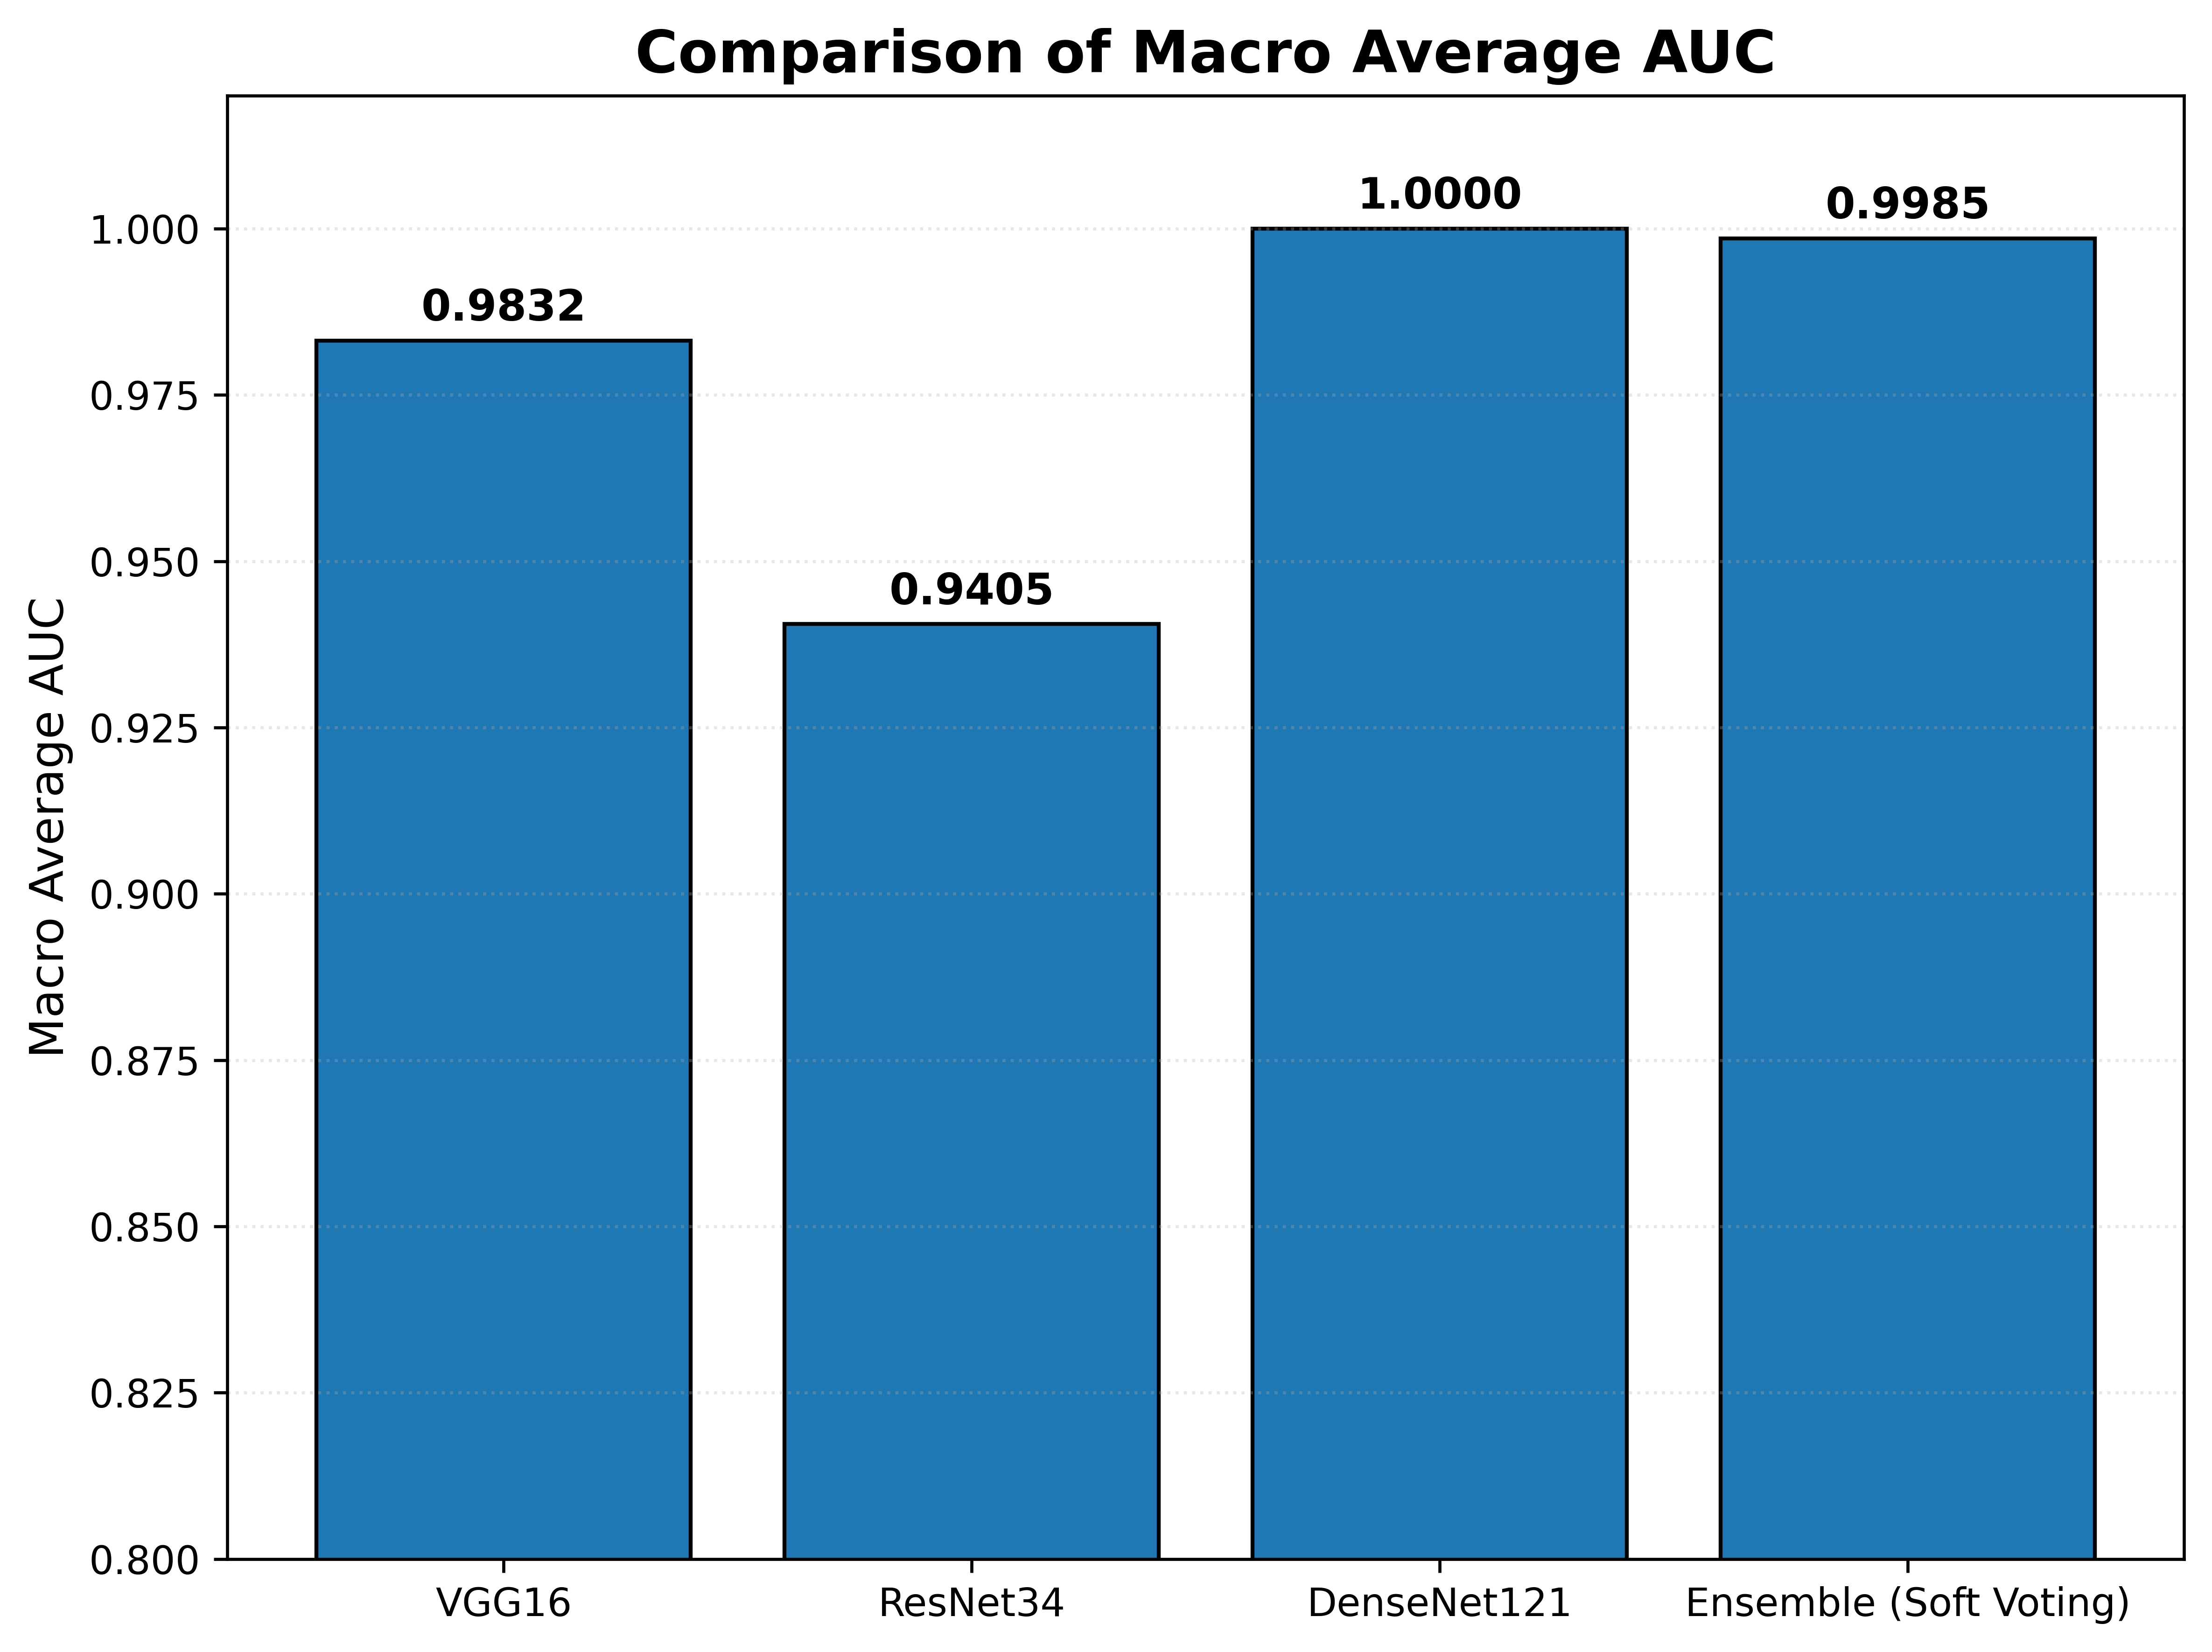

In [ ]:
plt.figure(figsize=(8,6), dpi=600)

bars = plt.bar(
    auc_df["Model"],
    auc_df["Macro-Avg AUC"],
    edgecolor="black",
    linewidth=1
)

plt.ylim(0.8,1.02)

plt.ylabel(
    "Macro Average AUC",
    fontsize=12
)

plt.title(
    "Comparison of Macro Average AUC",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.3
)

for bar, val in zip(bars, auc_df["Macro-Avg AUC"]):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        val+0.003,
        f"{val:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()


📊 HEATMAP KORELASI FEATURE (ENSEMBLE VOTING)
💾 Heatmap (predicted) saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/heatmap_korelasi_feature_ensemble_pred.png


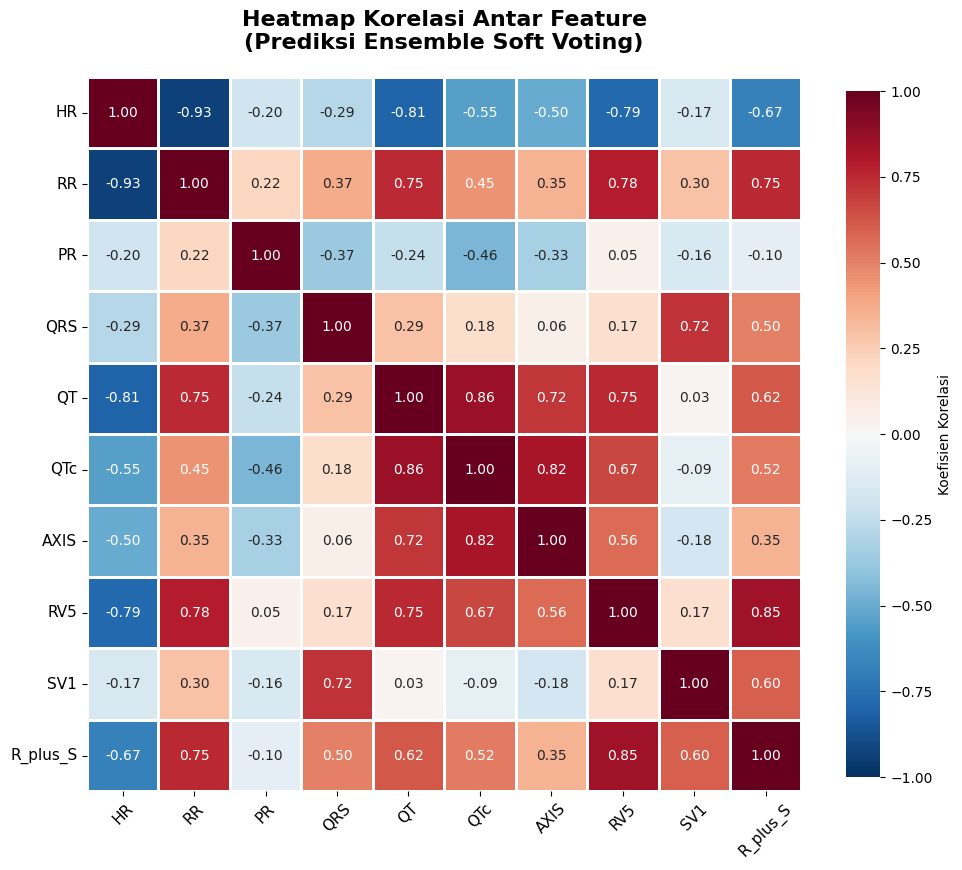

💾 Heatmap (actual) saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/heatmap_korelasi_feature_actual.png


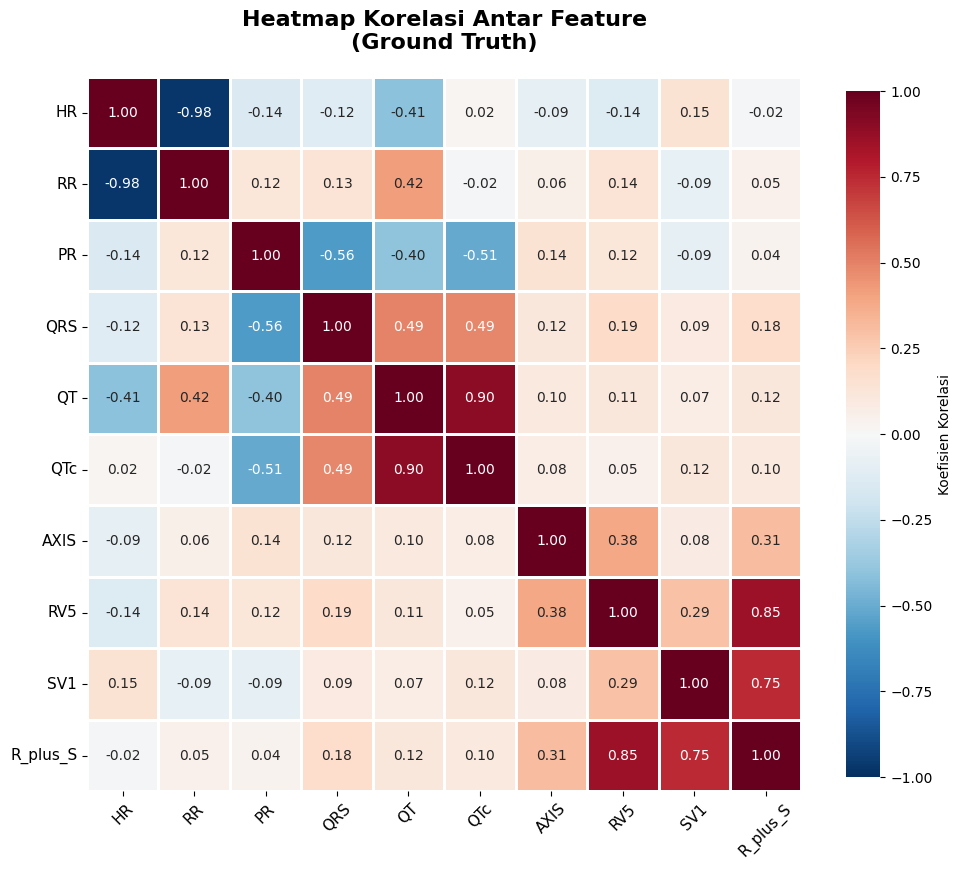

💾 Heatmap comparison saved to: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/heatmap_korelasi_perbandingan.png


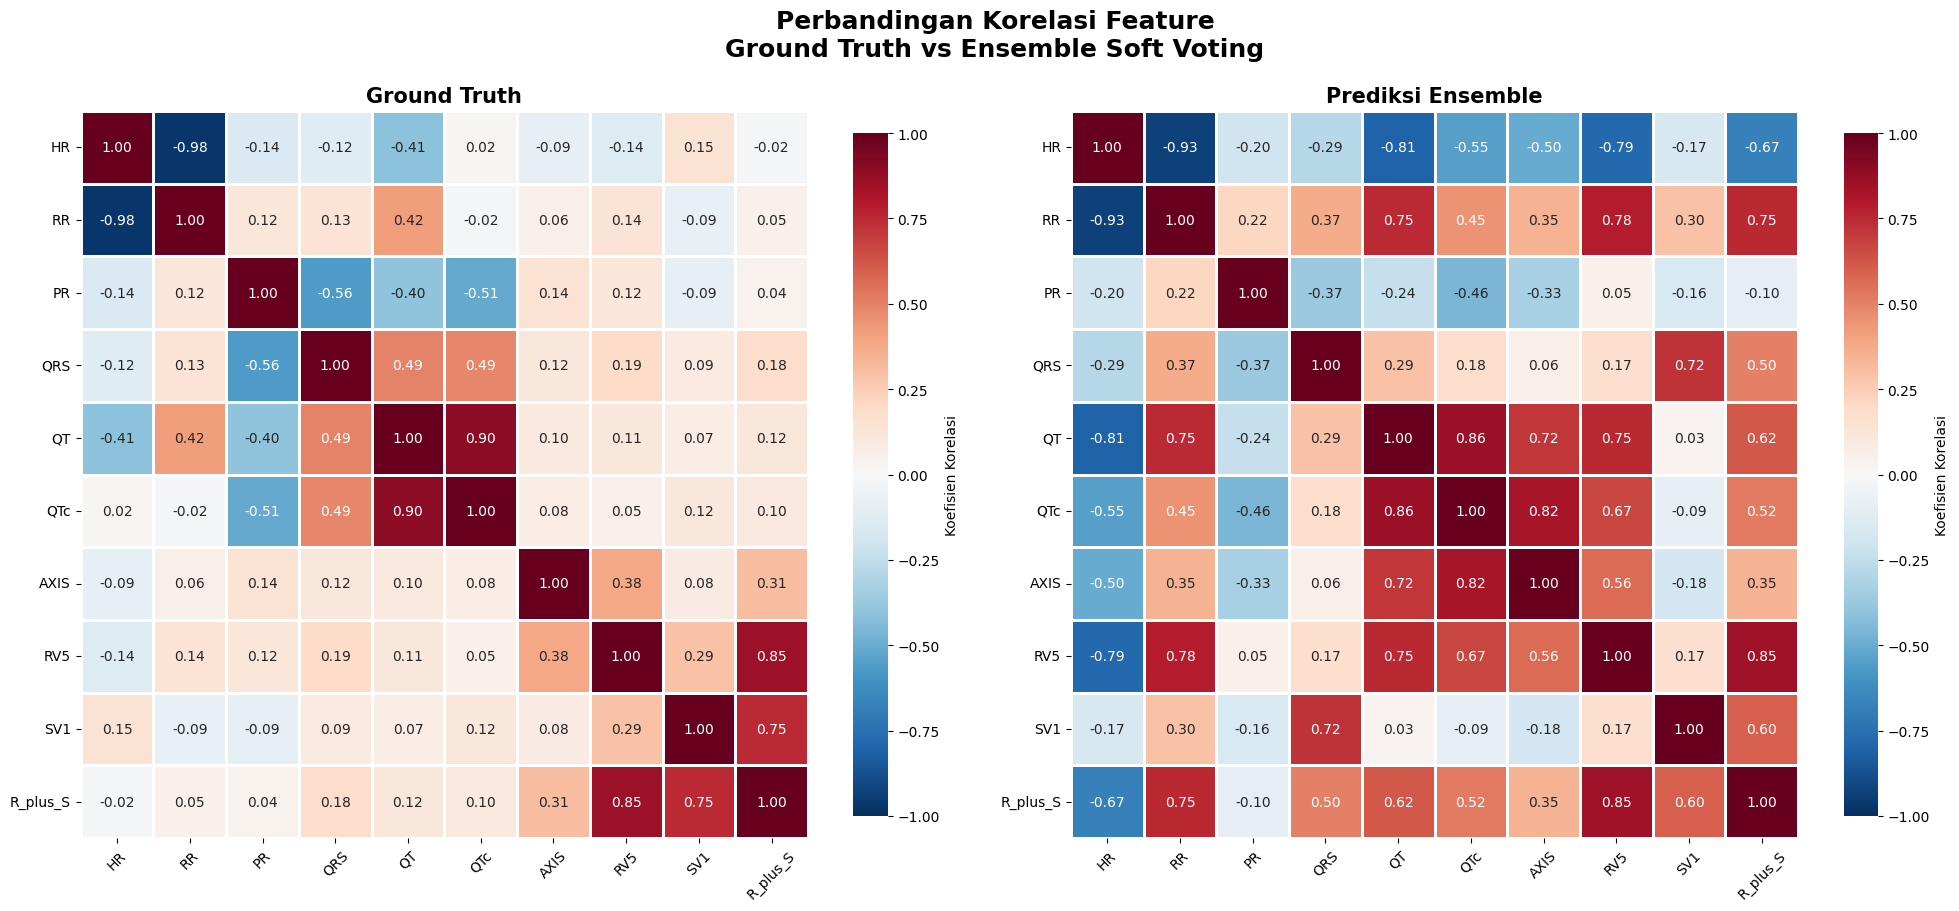


📋 Statistik Deskriptif Feature (Prediksi Ensemble):
            HR       RR       PR      QRS       QT      QTc     AXIS      RV5      SV1  R_plus_S
count  78.0000  78.0000  78.0000  78.0000  78.0000  78.0000  78.0000  78.0000  78.0000   78.0000
mean   -0.0439  -0.1106  -0.0289  -0.0065   0.0185   0.0393  -0.0052  -0.1508  -0.0764   -0.1753
std     0.3947   0.2784   0.1548   0.1769   0.3986   0.2871   0.2849   0.3904   0.2762    0.3332
min    -0.9032  -0.5693  -0.3300  -0.3051  -0.5875  -0.4695  -0.5810  -0.8121  -0.6058   -0.5791
25%    -0.3666  -0.3288  -0.1452  -0.1443  -0.2891  -0.1630  -0.1844  -0.4587  -0.2645   -0.3789
50%    -0.0661  -0.1591  -0.0363  -0.0301  -0.0817  -0.0457  -0.0338  -0.2251  -0.0958   -0.2658
75%     0.2888   0.0881   0.0690   0.1390   0.1768   0.2029   0.1256   0.0872   0.0604   -0.1107
max     0.7171   0.5222   0.3680   0.4040   1.0796   0.7162   0.8241   0.7520   0.8604    1.1388

🎉 SELESAI!

File output:
 - ensemble_prediction_table.csv
 - roc_curves_a

In [ ]:
# ------------------------------------------------------------------
# 14. HEATMAP KORELASI FEATURE UNTUK ENSEMBLE VOTING
# ------------------------------------------------------------------
print("\n" + "=" * 90)
print("📊 HEATMAP KORELASI FEATURE (ENSEMBLE VOTING)")
print("=" * 90)

FEATURE_COLS = [
    'HR', 'RR', 'PR', 'QRS', 'QT',
    'QTc', 'AXIS', 'RV5', 'SV1', 'R_plus_S'
]

# ============================================================
# Data Prediksi & Ground Truth
# ============================================================
reg_preds_all   = ens_reg_preds
reg_targets_all = ens_reg_targets

pred_features_df = pd.DataFrame(reg_preds_all, columns=FEATURE_COLS)
actual_features_df = pd.DataFrame(reg_targets_all, columns=FEATURE_COLS)

corr_pred   = pred_features_df.corr()
corr_actual = actual_features_df.corr()


# ============================================================
# STYLE HEATMAP
# ============================================================
HEATMAP_STYLE = dict(
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size":10},
    cbar_kws={
        "label":"Koefisien Korelasi",
        "shrink":0.85
    }
)


# ============================================================
# A. Heatmap Prediksi
# ============================================================
fig, ax = plt.subplots(figsize=(10,9))

sns.heatmap(
    corr_pred,
    ax=ax,
    **HEATMAP_STYLE
)

ax.set_title(
    "Heatmap Korelasi Antar Feature\n(Prediksi Ensemble Soft Voting)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()

heatmap_pred_path = os.path.join(
    CFG.OUTPUT_DIR,
    "heatmap_korelasi_feature_ensemble_pred.png"
)

plt.savefig(
    heatmap_pred_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"💾 Heatmap (predicted) saved to: {heatmap_pred_path}")

plt.show()


# ============================================================
# B. Heatmap Aktual
# ============================================================
fig, ax = plt.subplots(figsize=(10,9))

sns.heatmap(
    corr_actual,
    ax=ax,
    **HEATMAP_STYLE
)

ax.set_title(
    "Heatmap Korelasi Antar Feature\n(Ground Truth)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()

heatmap_actual_path = os.path.join(
    CFG.OUTPUT_DIR,
    "heatmap_korelasi_feature_actual.png"
)

plt.savefig(
    heatmap_actual_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"💾 Heatmap (actual) saved to: {heatmap_actual_path}")

plt.show()


# ============================================================
# C. Perbandingan
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(20,9)
)

sns.heatmap(
    corr_actual,
    ax=axes[0],
    **HEATMAP_STYLE
)

axes[0].set_title(
    "Ground Truth",
    fontsize=15,
    fontweight="bold"
)

axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    corr_pred,
    ax=axes[1],
    **HEATMAP_STYLE
)

axes[1].set_title(
    "Prediksi Ensemble",
    fontsize=15,
    fontweight="bold"
)

axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(
    "Perbandingan Korelasi Feature\nGround Truth vs Ensemble Soft Voting",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

heatmap_compare_path = os.path.join(
    CFG.OUTPUT_DIR,
    "heatmap_korelasi_perbandingan.png"
)

plt.savefig(
    heatmap_compare_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"💾 Heatmap comparison saved to: {heatmap_compare_path}")

plt.show()


# ============================================================
# D. Statistik
# ============================================================
print("\n📋 Statistik Deskriptif Feature (Prediksi Ensemble):")
print(pred_features_df.describe().round(4).to_string())


print("\n" + "=" * 90)
print("🎉 SELESAI!")
print("=" * 90)

print("\nFile output:")
print(" - ensemble_prediction_table.csv")
print(" - roc_curves_all_models.png")
print(" - auc_summary.csv")
print(" - auc_macro_comparison.png")
print(" - heatmap_korelasi_feature_ensemble_pred.png")
print(" - heatmap_korelasi_feature_actual.png")
print(" - heatmap_korelasi_perbandingan.png")


📊 PERBANDINGAN KINERJA MODEL
      Model  Accuracy
      VGG16  0.923077
   ResNet34  0.910256
DenseNet121  1.000000
   Ensemble  0.974359


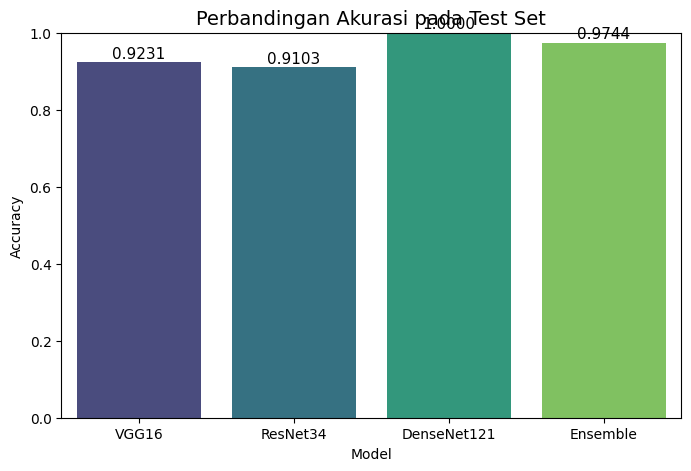

✅ Bar chart disimpan di: /content/drive/MyDrive/DataSet/ptbdb/All_Assets/multitask_outputs/accuracy_comparison.png

📊 EVALUASI REGRESI (Ensemble)

📋 Regresi per fitur:
   Fitur       MAE         MSE
      HR 76.918343 6101.819824
      RR  0.916302    0.879408
      PR  0.171018    0.042982
     QRS  0.195919    0.055015
      QT  0.467055    0.269805
     QTc  0.425392    0.229722
    AXIS 47.277126 3506.166260
     RV5  1.100578    1.408790
     SV1  1.010476    1.169960
R_plus_S  2.052155    4.662709

✅ Overall MAE : 13.0534
✅ Overall MSE : 961.6705


In [ ]:

# ------------------------------------------------------------------
# 14. TABEL PERBANDINGAN AKURASI + BAR CHART
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 PERBANDINGAN KINERJA MODEL")
print("="*60)

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [res["accuracy"] for res in results.values()]
})
print(comparison_df.to_string(index=False))

# Simpan tabel ke CSV
comparison_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "accuracy_comparison.csv"), index=False)

# Bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette="viridis")
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi pada Test Set", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
for i, acc in enumerate(comparison_df["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha="center", fontsize=11)
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "accuracy_comparison.png"), dpi=300)
plt.show()
print(f"✅ Bar chart disimpan di: {CFG.OUTPUT_DIR}/accuracy_comparison.png")

# ------------------------------------------------------------------
# 15. EVALUASI REGRESI (10 fitur klinis) pada Ensemble
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 EVALUASI REGRESI (Ensemble)")
print("="*60)

feature_names = ['HR','RR','PR','QRS','QT','QTc','AXIS','RV5','SV1','R_plus_S']

mae_per_feature = mean_absolute_error(ens_reg_targets, ens_reg_preds, multioutput='raw_values')
mse_per_feature = mean_squared_error(ens_reg_targets, ens_reg_preds, multioutput='raw_values')

reg_metrics_df = pd.DataFrame({
    "Fitur": feature_names,
    "MAE": mae_per_feature,
    "MSE": mse_per_feature
})
print("\n📋 Regresi per fitur:")
print(reg_metrics_df.to_string(index=False))

overall_mae = mean_absolute_error(ens_reg_targets, ens_reg_preds)
overall_mse = mean_squared_error(ens_reg_targets, ens_reg_preds)
print(f"\n✅ Overall MAE : {overall_mae:.4f}")
print(f"✅ Overall MSE : {overall_mse:.4f}")

reg_metrics_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "regression_metrics_ensemble.csv"), index=False)


In [ ]:
# ------------------------------------------------------------------
# 7. PREDIKSI PER SAMPEL: SETIAP MODEL + ENSEMBLE SOFT VOTING
# ------------------------------------------------------------------
print("=" * 70)
print("📊 MEMBUAT TABEL PREDIKSI ENSEMBLE SOFT VOTING")
print("=" * 70)

all_results = []

# Define CLASS_NAMES and SHORT_LABELS as they are used later
# Assuming CLASS_NAMES is the same as class_names defined earlier in the notebook
CLASS_NAMES = class_names
SHORT_LABELS = {
    "Normal": "Normal",
    "Myocardial_Infarction": "MI",
    "Other_Heart_Disease": "Other"
}

with torch.no_grad():
    sample_counter = 0
    for batch in tqdm(test_loader, desc="Predicting"):
        # Corrected unpacking: ECGDataset.__getitem__ returns 3 values (image, class_label, regression_target)
        images, labels, reg_targets = batch
        images = images.to(CFG.DEVICE)
        batch_size = images.size(0)

        # Kumpulkan probabilitas dari setiap model
        probs_per_model = {}
        preds_per_model = {}

        for model_name, model in models_dict.items():
            logits, _ = model(images)
            probs = torch.softmax(logits, dim=1)          # (B, 3)
            preds = torch.argmax(probs, dim=1)             # (B,)
            probs_per_model[model_name] = probs.cpu().numpy()
            preds_per_model[model_name] = preds.cpu().numpy()

        # Ensemble Soft Voting
        all_probs = np.stack(list(probs_per_model.values()), axis=0)  # (3, B, 3)
        avg_probs = all_probs.mean(axis=0)                            # (B, 3)
        ens_preds = np.argmax(avg_probs, axis=1)                      # (B,)
        ens_confidence = np.max(avg_probs, axis=1)                    # (B,)

        for i in range(batch_size):
            sample_counter += 1
            sample_id = f"U{sample_counter:03d}"
            # Get actual_label string from numerical label using CLASS_NAMES
            actual_label_numerical = labels[i].item()
            actual_label_string = CLASS_NAMES[actual_label_numerical]

            row = {
                "Sampel": sample_id,
                "Label Aktual": SHORT_LABELS[actual_label_string],
                "VGG16":  SHORT_LABELS[CLASS_NAMES[preds_per_model["VGG16"][i]]],
                "ResNet34": SHORT_LABELS[CLASS_NAMES[preds_per_model["ResNet34"][i]]],
                "DenseNet121": SHORT_LABELS[CLASS_NAMES[preds_per_model["DenseNet121"][i]]],
                "Soft Voting": SHORT_LABELS[CLASS_NAMES[ens_preds[i]]],
                "Confidence": f"{ens_confidence[i] * 100:.1f}%",
            }
            all_results.append(row)

📊 MEMBUAT TABEL PREDIKSI ENSEMBLE SOFT VOTING


Predicting: 100%|██████████| 1/1 [00:13<00:00, 13.71s/it]


In [ ]:
# ------------------------------------------------------------------
# 8. BUAT DATAFRAME & TAMPILKAN TABEL
# ------------------------------------------------------------------
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 90)
print("Ketiga model yang telah dilatih diintegrasikan melalui mekanisme soft voting.")
print("Berikut adalah contoh hasil prediksi ensemble pada beberapa sampel data uji:")
print("=" * 90)

# Tampilkan 7 sampel pertama (sesuai contoh output)
display_df = results_df.head(7)
print(display_df.to_string(index=False))


Ketiga model yang telah dilatih diintegrasikan melalui mekanisme soft voting.
Berikut adalah contoh hasil prediksi ensemble pada beberapa sampel data uji:
Sampel Label Aktual  VGG16 ResNet34 DenseNet121 Soft Voting Confidence
  U001           MI     MI       MI          MI          MI      98.9%
  U002        Other Normal    Other       Other       Other      56.6%
  U003           MI     MI       MI          MI          MI      95.8%
  U004           MI     MI       MI          MI          MI      99.4%
  U005           MI  Other       MI          MI          MI      81.2%
  U006           MI     MI       MI          MI          MI      98.9%
  U007           MI     MI       MI          MI          MI      98.9%


In [ ]:
# ------------------------------------------------------------------
# 9. TAMPILKAN SAMPEL LEBIH LENGKAP (20 SAMPEL)
# ------------------------------------------------------------------
print("\n" + "-" * 90)
print("📋 Tabel Lengkap (20 Sampel Pertama):")
print("-" * 90)
display_20 = results_df.head(20)
print(display_20.to_string(index=False))


------------------------------------------------------------------------------------------
📋 Tabel Lengkap (20 Sampel Pertama):
------------------------------------------------------------------------------------------
Sampel Label Aktual  VGG16 ResNet34 DenseNet121 Soft Voting Confidence
  U001           MI     MI       MI          MI          MI      98.9%
  U002        Other Normal    Other       Other       Other      56.6%
  U003           MI     MI       MI          MI          MI      95.8%
  U004           MI     MI       MI          MI          MI      99.4%
  U005           MI  Other       MI          MI          MI      81.2%
  U006           MI     MI       MI          MI          MI      98.9%
  U007           MI     MI       MI          MI          MI      98.9%
  U008           MI     MI    Other          MI          MI      69.1%
  U009           MI     MI       MI          MI          MI      99.4%
  U010           MI     MI       MI          MI          MI      98.8%

In [ ]:
# ------------------------------------------------------------------
# 10. STATISTIK RINGKASAN
# ------------------------------------------------------------------
total_samples = len(results_df)
correct_ensemble = sum(
    1 for _, row in results_df.iterrows()
    if row["Label Aktual"] == row["Soft Voting"]
)
ensemble_accuracy = correct_ensemble / total_samples * 100

# Hitung akurasi per model
model_accuracies = {}
for model_col in ["VGG16", "ResNet34", "DenseNet121", "Soft Voting"]:
    correct = sum(
        1 for _, row in results_df.iterrows()
        if row["Label Aktual"] == row[model_col]
    )
    model_accuracies[model_col] = correct / total_samples * 100

print("\n" + "=" * 90)
print("📊 RINGKASAN AKURASI PADA TEST SET")
print("=" * 90)
for model_name, acc in model_accuracies.items():
    marker = "🏆" if model_name == "Soft Voting" else "  "
    print(f"  {marker} {model_name:15s}: {acc:.2f}% ({int(acc/100*total_samples)}/{total_samples} benar)")



📊 RINGKASAN AKURASI PADA TEST SET
     VGG16          : 92.31% (72/78 benar)
     ResNet34       : 91.03% (71/78 benar)
     DenseNet121    : 100.00% (78/78 benar)
  🏆 Soft Voting    : 97.44% (76/78 benar)


In [ ]:
# ------------------------------------------------------------------
# 12. ANALISIS DISAGREEMENT ANTAR MODEL
# ------------------------------------------------------------------
print("\n" + "=" * 90)
print("📊 ANALISIS DISAGREEMENT ANTAR MODEL")
print("=" * 90)

agree_count = 0
disagree_count = 0
disagree_samples = []

for _, row in results_df.iterrows():
    preds = [row["VGG16"], row["ResNet34"], row["DenseNet121"]]
    if len(set(preds)) == 1:
        agree_count += 1
    else:
        disagree_count += 1
        disagree_samples.append(row)

print(f"  Semua model sepakat  : {agree_count}/{total_samples} ({agree_count/total_samples*100:.1f}%)")
print(f"  Terdapat disagreement: {disagree_count}/{total_samples} ({disagree_count/total_samples*100:.1f}%)")

if disagree_samples:
    print(f"\n📋 Contoh sampel dengan disagreement (maks 10):")
    disagree_df = pd.DataFrame(disagree_samples[:10])
    print(disagree_df.to_string(index=False))

print("\n" + "=" * 90)
print("🎉 SELESAI!")
print("=" * 90)


📊 ANALISIS DISAGREEMENT ANTAR MODEL
  Semua model sepakat  : 67/78 (85.9%)
  Terdapat disagreement: 11/78 (14.1%)

📋 Contoh sampel dengan disagreement (maks 10):
Sampel Label Aktual  VGG16 ResNet34 DenseNet121 Soft Voting Confidence
  U002        Other Normal    Other       Other       Other      56.6%
  U005           MI  Other       MI          MI          MI      81.2%
  U008           MI     MI    Other          MI          MI      69.1%
  U019        Other Normal    Other       Other       Other      63.1%
  U031       Normal Normal    Other      Normal      Normal      61.0%
  U035        Other  Other   Normal       Other       Other      74.6%
  U044       Normal Normal    Other      Normal      Normal      72.8%
  U047        Other Normal    Other       Other       Other      78.4%
  U057        Other     MI       MI       Other          MI      54.9%
  U067        Other     MI       MI       Other          MI      65.4%

🎉 SELESAI!


In [ ]:
  # ------------------------------------------------------------------
# 16. 5-FOLD CROSS VALIDATION (SEMUA MODEL)
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 5-FOLD CROSS VALIDATION (VGG16, ResNet34, DenseNet121)")
print("="*60)
print("⚠️  Proses ini akan melatih 3 model x 5 fold = 15 kali training.")
print("⏳ Perkiraan waktu: 30-60 menit (tergantung GPU).")
print("💡 Tips: Jika ingin cepat, ubah CFG.EPOCHS = 5 di bagian Config.\n")

# Ambil dataset full training dan label untuk StratifiedKFold
train_full_df = pd.read_csv(CFG.TRAIN_CSV)
labels_full = train_full_df["label"].map({"Normal":0, "Myocardial_Infarction":1, "Other_Heart_Disease":2}).values
train_full_dataset = ECGDataset(CFG.TRAIN_CSV, CFG.DATASET_DIR, transform=train_transform)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary untuk menyimpan hasil semua model
cv_results_all = {}

# Daftar backbone yang akan diuji
backbones = ["vgg16", "resnet34", "densenet121"]

for backbone in backbones:
    print(f"\n{'='*50}")
    print(f"🚀 MENJALANKAN 5-FOLD CV UNTUK: {backbone.upper()}")
    print(f"{'='*50}")

    fold_accuracies = []
    fold_histories = []  # opsional: simpan history tiap fold

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_full_dataset)), labels_full)):
        print(f"\n🔹 Fold {fold+1}/{5}")

        train_subset = Subset(train_full_dataset, train_idx)
        val_subset = Subset(train_full_dataset, val_idx)

        train_loader_cv = DataLoader(train_subset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                                     num_workers=CFG.NUM_WORKERS, pin_memory=True)
        val_loader_cv = DataLoader(val_subset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                                   num_workers=CFG.NUM_WORKERS, pin_memory=True)

        # Inisialisasi model baru tiap fold
        model_cv = MultiTaskModel(backbone).to(CFG.DEVICE)
        optimizer = optim.Adam(model_cv.parameters(), lr=CFG.LEARNING_RATE)
        criterion_cls = nn.CrossEntropyLoss()
        # Gunakan scheduler agar lebih stabil (opsional)
        # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

        best_val_acc = 0.0
        patience_counter = 0

        for epoch in range(CFG.EPOCHS):
            # ---------- TRAINING ----------
            model_cv.train()
            for images, labels, _ in train_loader_cv:
                images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)
                optimizer.zero_grad()
                class_logits, _ = model_cv(images)
                loss = criterion_cls(class_logits, labels)
                loss.backward()
                optimizer.step()

            # ---------- VALIDASI ----------
            model_cv.eval()
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for images, labels, _ in val_loader_cv:
                    images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)
                    class_logits, _ = model_cv(images)
                    preds = torch.argmax(class_logits, dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)
            val_acc = val_correct / val_total

            # Early Stopping & Simpan Best
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= CFG.PATIENCE:
                    # print(f"   Early stopping di epoch {epoch+1}")
                    break

        fold_accuracies.append(best_val_acc)
        print(f"   ✅ Best val accuracy: {best_val_acc:.4f}")

    # Simpan hasil untuk backbone ini
    cv_results_all[backbone] = fold_accuracies

    # Tampilkan statistik per model
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f"\n📈 Hasil CV untuk {backbone.upper()}:")
    print(f"   Akurasi tiap fold: {[f'{acc:.4f}' for acc in fold_accuracies]}")
    print(f"   Mean Accuracy : {mean_acc:.4f}")
    print(f"   Std Accuracy  : {std_acc:.4f}")


📊 5-FOLD CROSS VALIDATION (VGG16, ResNet34, DenseNet121)
⚠️  Proses ini akan melatih 3 model x 5 fold = 15 kali training.
⏳ Perkiraan waktu: 30-60 menit (tergantung GPU).
💡 Tips: Jika ingin cepat, ubah CFG.EPOCHS = 5 di bagian Config.


🚀 MENJALANKAN 5-FOLD CV UNTUK: VGG16

🔹 Fold 1/5
   ✅ Best val accuracy: 0.6986

🔹 Fold 2/5
   ✅ Best val accuracy: 0.7123

🔹 Fold 3/5
   ✅ Best val accuracy: 0.7222

🔹 Fold 4/5
   ✅ Best val accuracy: 0.7083

🔹 Fold 5/5
   ✅ Best val accuracy: 0.7083

📈 Hasil CV untuk VGG16:
   Akurasi tiap fold: ['0.6986', '0.7123', '0.7222', '0.7083', '0.7083']
   Mean Accuracy : 0.7100
   Std Accuracy  : 0.0076

🚀 MENJALANKAN 5-FOLD CV UNTUK: RESNET34

🔹 Fold 1/5
   ✅ Best val accuracy: 0.7945

🔹 Fold 2/5
   ✅ Best val accuracy: 0.8630

🔹 Fold 3/5
   ✅ Best val accuracy: 0.8750

🔹 Fold 4/5
   ✅ Best val accuracy: 0.8611

🔹 Fold 5/5
   ✅ Best val accuracy: 0.8750

📈 Hasil CV untuk RESNET34:
   Akurasi tiap fold: ['0.7945', '0.8630', '0.8750', '0.8611', '0.8750']
   

OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 11.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.31 GiB is allocated by PyTorch, and 99.38 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
# ------------------------------------------------------------------
# 17. TABEL PERBANDINGAN HASIL CV SEMUA MODEL
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 PERBANDINGAN HASIL 5-FOLD CV")
print("="*60)

# Buat DataFrame perbandingan
cv_comparison_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5]
})

for backbone, accs in cv_results_all.items():
    cv_comparison_df[backbone.upper()] = accs

# Tambahkan baris Mean dan Std
mean_row = {"Fold": "Mean"}
std_row = {"Fold": "Std"}
for backbone, accs in cv_results_all.items():
    mean_row[backbone.upper()] = np.mean(accs)
    std_row[backbone.upper()] = np.std(accs)

cv_comparison_df = pd.concat([
    cv_comparison_df,
    pd.DataFrame([mean_row]),
    pd.DataFrame([std_row])
], ignore_index=True)

print("\n📋 Tabel Perbandingan 5-Fold CV:")
print(cv_comparison_df.to_string(index=False))

# Simpan ke CSV
cv_comparison_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "cv_comparison_all_models.csv"), index=False)
print(f"\n✅ Tabel CV disimpan di: {CFG.OUTPUT_DIR}/cv_comparison_all_models.csv")

In [ ]:
# ------------------------------------------------------------------
# 18. VISUALISASI PERBANDINGAN HASIL CV (BAR CHART + ERROR BAR)
# ------------------------------------------------------------------
print("\n" + "="*60)
print("📊 VISUALISASI PERBANDINGAN 5-FOLD CV")
print("="*60)

# Ambil data Mean & Std untuk plotting
plot_data = []
for backbone, accs in cv_results_all.items():
    plot_data.append({
        "Model": backbone.upper(),
        "Mean": np.mean(accs),
        "Std": np.std(accs)
    })
plot_df = pd.DataFrame(plot_data)

# Bar chart dengan error bar (standar deviasi)
plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["Model"], plot_df["Mean"], yerr=plot_df["Std"],
               capsize=10, color=['#1f77b4', '#ff7f0e', '#2ca02c'],
               edgecolor='black', linewidth=1.2)

# Tambahkan label nilai di atas bar
for bar, mean_val in zip(bars, plot_df["Mean"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mean_val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Perbandingan 5-Fold Cross Validation Accuracy', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "cv_comparison_all_models.png"), dpi=300)
plt.show()
print(f"✅ Grafik CV disimpan di: {CFG.OUTPUT_DIR}/cv_comparison_all_models.png")



In [ ]:
# ------------------------------------------------------------------
# 19. BOXPLOT DISTRIBUSI AKURASI PER FOLD (opsional)
# ------------------------------------------------------------------
# Untuk melihat sebaran akurasi tiap fold
plt.figure(figsize=(10, 6))
data_to_plot = [cv_results_all[backbone] for backbone in backbones]
labels = [b.upper() for b in backbones]

bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))

# Warna box
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Distribusi Akurasi 5-Fold Cross Validation', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "cv_boxplot_all_models.png"), dpi=300)
plt.show()
print(f"✅ Boxplot CV disimpan di: {CFG.OUTPUT_DIR}/cv_boxplot_all_models.png")

print("\n🎉 SEMUA PROSES CROSS VALIDATION SELESAI!")

In [ ]:
# ------------------------------------------------------------------
# 17. SIMPAN SEMUA CLASSIFICATION REPORT (dalam CSV)
# ------------------------------------------------------------------
for name, res in results.items():
    report_df = pd.DataFrame(res["report"]).transpose()
    report_df.to_csv(os.path.join(CFG.OUTPUT_DIR, f"report_{name}.csv"))

print("\n" + "="*60)
print("🎉 EVALUASI SELESAI!")
print("="*60)
print(f"📁 Semua hasil tersimpan di: {CFG.OUTPUT_DIR}")
print("   - confusion_matrices_all.png")
print("   - accuracy_comparison.png / .csv")
print("   - regression_metrics_ensemble.csv")
print("   - cv_results_resnet34.csv")
print("   - report_*.csv (untuk setiap model & ensemble)")